# Used Car Price Prediction (India) — CarDekho Dataset

**Goal**: Help a used-car seller in India get a realistic, data-driven price estimate (as a
range, not a false-precision single number) for their car, based on real historical sale
listings.

**Approach**: full pipeline from raw messy scraped data through EDA, feature engineering,
baseline models, advanced boosted-tree models, hyperparameter tuning, and quantile
regression for an honest price range — matching how this would actually be used in an app.

**Data sources**: two real CarDekho used-car listing exports (see Data Loading section for
provenance and licensing notes).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Data Loading

Two CarDekho-sourced datasets:
- `car_details_basic.csv` — 4,340 listings, core fields only
- `car_details_v3.csv` — 8,128 listings, includes mileage/engine/power/torque/seats

Both are widely-used public re-hostings of the original Kaggle "Vehicle dataset from
CarDekho" listings (cardekho.com), used here for a portfolio project, not commercial
resale of data.


In [2]:
basic = pd.read_csv("../data/car_details_basic.csv")
ext = pd.read_csv("../data/car_details_v3.csv")

print("basic:", basic.shape)
print("extended:", ext.shape)
basic.head()


basic: (4340, 8)
extended: (8128, 13)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [3]:
ext.head()


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


## 2. Combining the Two Sources

Before blindly concatenating, check how much the two files actually overlap (same
name+year+price+km_driven). If they're mostly the same listings, merging naively would
double-count them and bias the model.


In [4]:
key_cols = ["name", "year", "selling_price", "km_driven"]
basic_keys = set(basic[key_cols].apply(tuple, axis=1))
ext_keys = set(ext[key_cols].apply(tuple, axis=1))
overlap = basic_keys & ext_keys
print(f"Overlapping rows: {len(overlap)} out of {len(basic)} basic / {len(ext)} extended")
print(f"Overlap rate: {len(overlap) / len(basic) * 100:.1f}% of basic")


Overlapping rows: 59 out of 4340 basic / 8128 extended
Overlap rate: 1.4% of basic


Only ~1.4% overlap — these are largely different listings from different scrapes, so
combining them is legitimate and increases usable training data. The `basic` file lacks
`mileage`/`engine`/`max_power`/`torque`/`seats`; those will be `NaN` for rows that only
exist in `basic`. Tree-based models (XGBoost/LightGBM/CatBoost) handle `NaN` features
natively, so we don't need to drop those rows or those columns.


In [5]:
dupe_mask = basic[key_cols].apply(tuple, axis=1).isin(overlap)
basic_unique = basic[~dupe_mask].copy()
print(f"Dropping {dupe_mask.sum()} duplicate rows from basic before combining")

df = pd.concat([ext, basic_unique], ignore_index=True, sort=False)
print("Combined shape:", df.shape)
df.isnull().mean().sort_values(ascending=False) * 100


Dropping 64 duplicate rows from basic before combining
Combined shape: (12404, 13)


torque           36.262496
seats            36.254434
engine           36.254434
mileage          36.254434
max_power        36.206063
fuel              0.000000
km_driven         0.000000
selling_price     0.000000
year              0.000000
name              0.000000
owner             0.000000
seller_type       0.000000
transmission      0.000000
dtype: float64

## 3. Data Cleaning

The spec columns are messy real-world scraped text (`"23.4 kmpl"`, `"1248 CC"`, `"74 bhp"`,
and torque strings in at least three different formats — `"190Nm@ 2000rpm"`,
`"12.7@ 2,700(kgm@ rpm)"`, `"22.4 kgm at 1750-2750rpm"`). Torque is normalised to Nm
(1 kgm = 9.80665 Nm) since the raw column mixes units inconsistently.


In [6]:
def parse_number(x):
    if pd.isna(x):
        return np.nan
    m = re.search(r"[\d.]+", str(x))
    return float(m.group()) if m else np.nan


def parse_torque_nm(x):
    if pd.isna(x):
        return np.nan
    s = str(x).lower()
    m = re.search(r"[\d.]+", s)
    if not m:
        return np.nan
    value = float(m.group())
    # If the string mentions kgm (and not explicitly Nm), convert to Nm.
    if "kgm" in s and "nm" not in s.split("kgm")[0][-3:]:
        value *= 9.80665
    return value


df["mileage_kmpl"] = df["mileage"].apply(parse_number)
df["engine_cc"] = df["engine"].apply(parse_number)
df["max_power_bhp"] = df["max_power"].apply(parse_number)
df["torque_nm"] = df["torque"].apply(parse_torque_nm)

df["brand"] = df["name"].str.split().str[0].str.title()
df["current_year"] = df["year"].max() + 1  # treat most recent listing year as "now"
df["car_age"] = df["current_year"] - df["year"]

df["owner"] = df["owner"].replace({
    "Test Drive Car": "Test Drive Car",
    "0th Owner": "First Owner",  # occasional scrape artifact
})

print(df[["mileage", "mileage_kmpl", "engine", "engine_cc", "max_power", "max_power_bhp",
          "torque", "torque_nm"]].sample(5, random_state=RANDOM_STATE))


          mileage  mileage_kmpl   engine  engine_cc  max_power  max_power_bhp  \
1713    18.0 kmpl         18.00  1969 CC     1969.0    190 bhp         190.00   
7665    14.3 kmpl         14.30  1598 CC     1598.0  103.5 bhp         103.50   
2372    20.0 kmpl         20.00  1399 CC     1399.0  68.05 bhp          68.05   
10461         NaN           NaN      NaN        NaN        NaN            NaN   
3027   26.59 kmpl         26.59  1248 CC     1248.0     74 bhp          74.00   

               torque  torque_nm  
1713            400Nm      400.0  
7665   153Nm@ 3800rpm      153.0  
2372   160Nm@ 2000rpm      160.0  
10461             NaN        NaN  
3027   190Nm@ 2000rpm      190.0  


In [7]:
# Remove obviously invalid rows: zero/negative price, zero km_driven, implausible years
before = len(df)
df = df[(df["selling_price"] > 0) & (df["km_driven"] > 0) & (df["year"] >= 1990)]
print(f"Dropped {before - len(df)} invalid rows, {len(df)} remain")

# Cap extreme outliers at the 99.5th percentile rather than dropping (keeps rare
# luxury-car listings but stops them from dominating the loss function)
price_cap = df["selling_price"].quantile(0.995)
km_cap = df["km_driven"].quantile(0.995)
print(f"Price cap: {price_cap:,.0f}  |  KM-driven cap: {km_cap:,.0f}")
df["selling_price"] = df["selling_price"].clip(upper=price_cap)
df["km_driven"] = df["km_driven"].clip(upper=km_cap)


Dropped 1 invalid rows, 12403 remain
Price cap: 5,400,000  |  KM-driven cap: 260,000


## 4. Exploratory Data Analysis

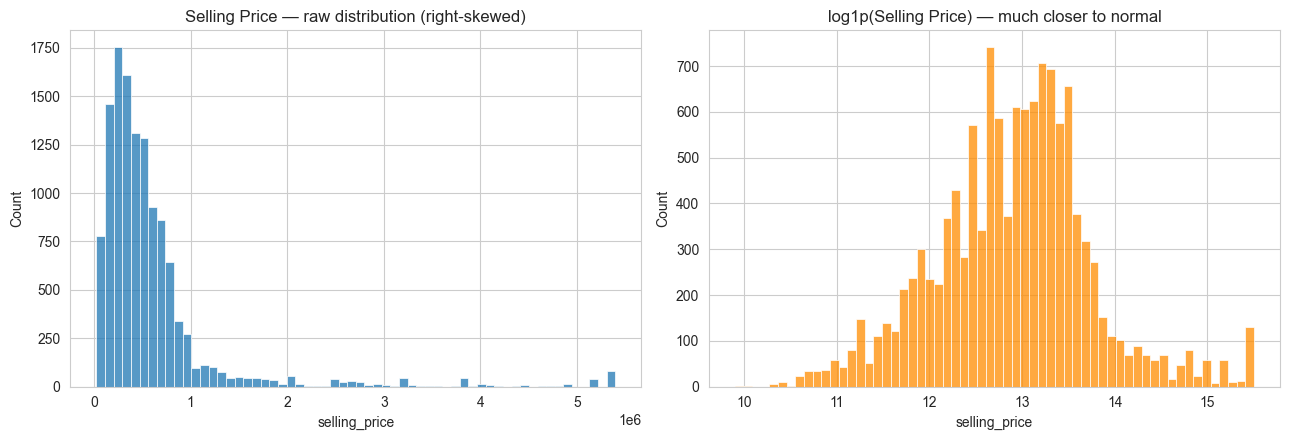

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df["selling_price"], bins=60, ax=axes[0])
axes[0].set_title("Selling Price — raw distribution (right-skewed)")
sns.histplot(np.log1p(df["selling_price"]), bins=60, ax=axes[1], color="darkorange")
axes[1].set_title("log1p(Selling Price) — much closer to normal")
plt.tight_layout()
plt.savefig("../models/eda_price_distribution.png", dpi=110)
plt.show()


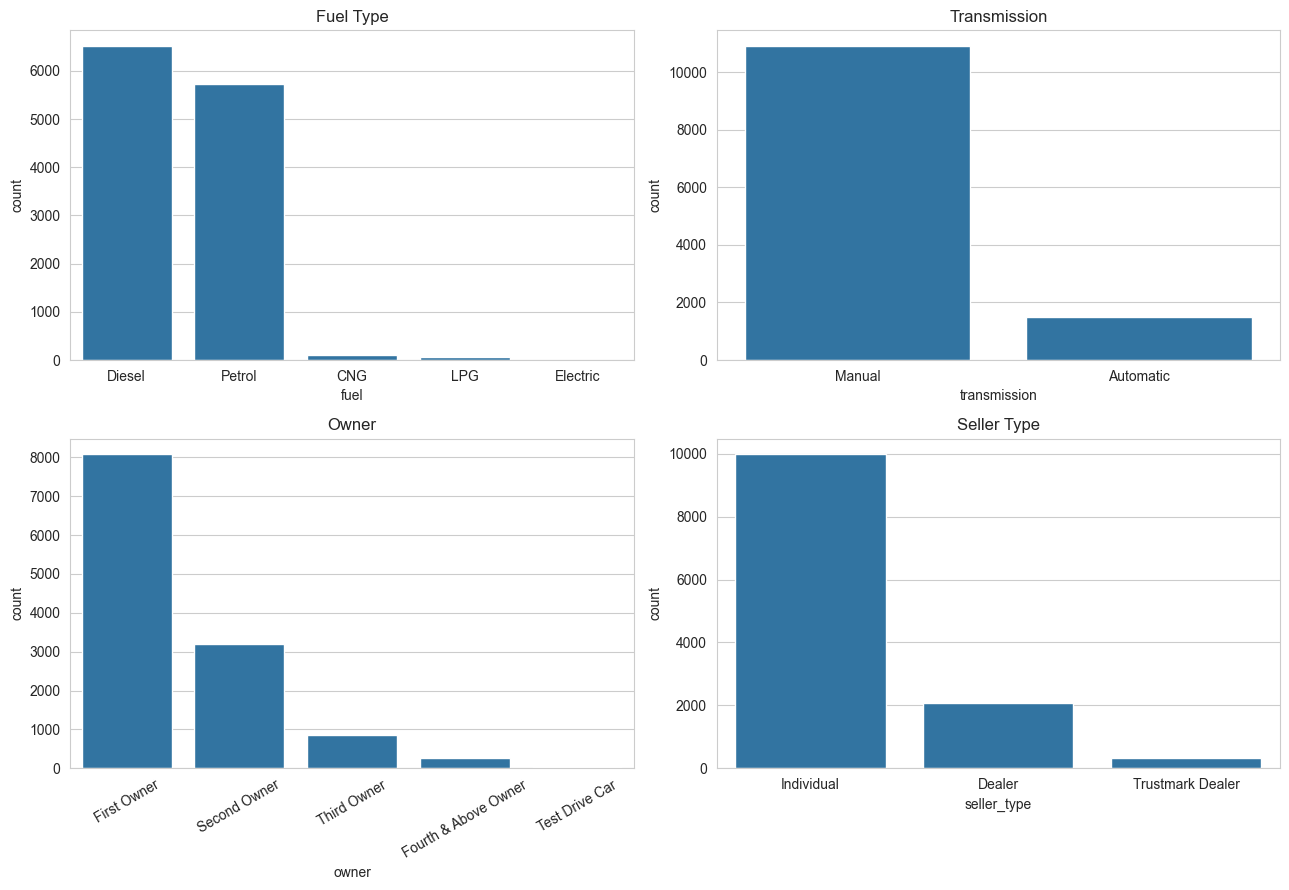

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.countplot(data=df, x="fuel", order=df["fuel"].value_counts().index, ax=axes[0, 0])
axes[0, 0].set_title("Fuel Type")
sns.countplot(data=df, x="transmission", ax=axes[0, 1])
axes[0, 1].set_title("Transmission")
sns.countplot(data=df, x="owner", order=df["owner"].value_counts().index, ax=axes[1, 0])
axes[1, 0].set_title("Owner")
axes[1, 0].tick_params(axis="x", rotation=30)
sns.countplot(data=df, x="seller_type", ax=axes[1, 1])
axes[1, 1].set_title("Seller Type")
plt.tight_layout()
plt.savefig("../models/eda_categoricals.png", dpi=110)
plt.show()


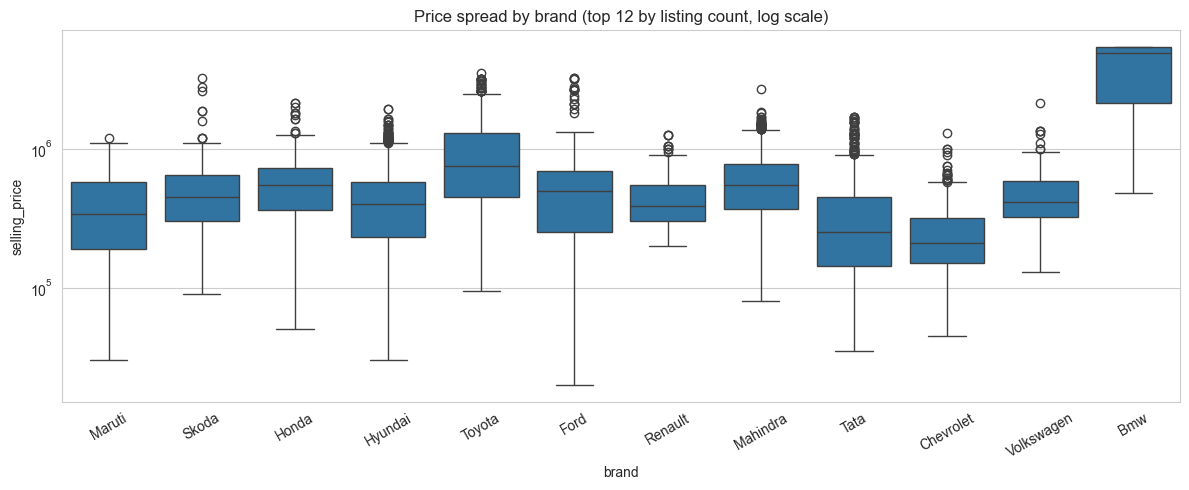

In [10]:
top_brands = df["brand"].value_counts().head(12).index
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df[df["brand"].isin(top_brands)], x="brand", y="selling_price", ax=ax)
ax.set_yscale("log")
ax.set_title("Price spread by brand (top 12 by listing count, log scale)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../models/eda_price_by_brand.png", dpi=110)
plt.show()


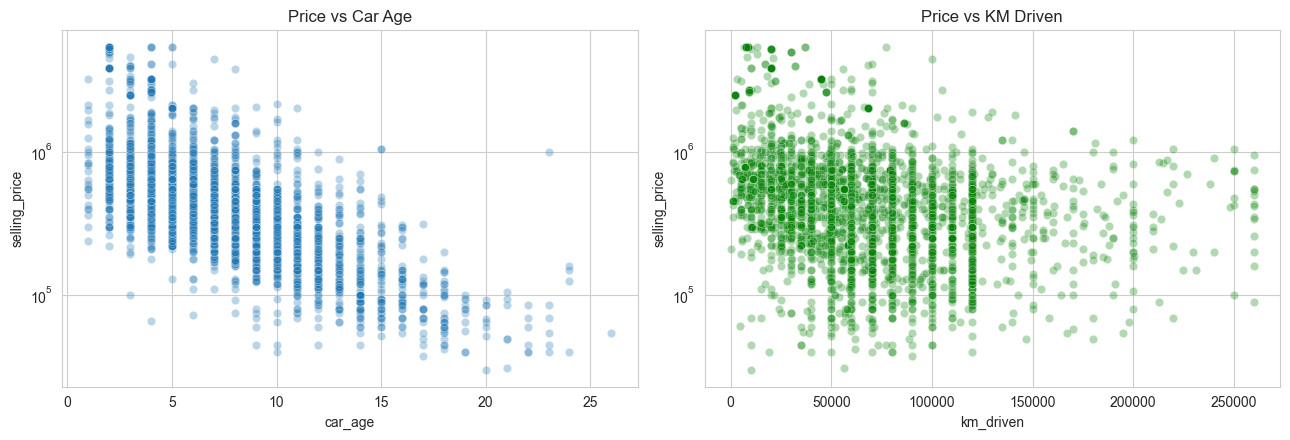

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.scatterplot(data=df.sample(min(3000, len(df)), random_state=RANDOM_STATE),
                 x="car_age", y="selling_price", alpha=0.3, ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Price vs Car Age")
sns.scatterplot(data=df.sample(min(3000, len(df)), random_state=RANDOM_STATE),
                 x="km_driven", y="selling_price", alpha=0.3, ax=axes[1], color="green")
axes[1].set_yscale("log")
axes[1].set_title("Price vs KM Driven")
plt.tight_layout()
plt.savefig("../models/eda_price_vs_age_km.png", dpi=110)
plt.show()


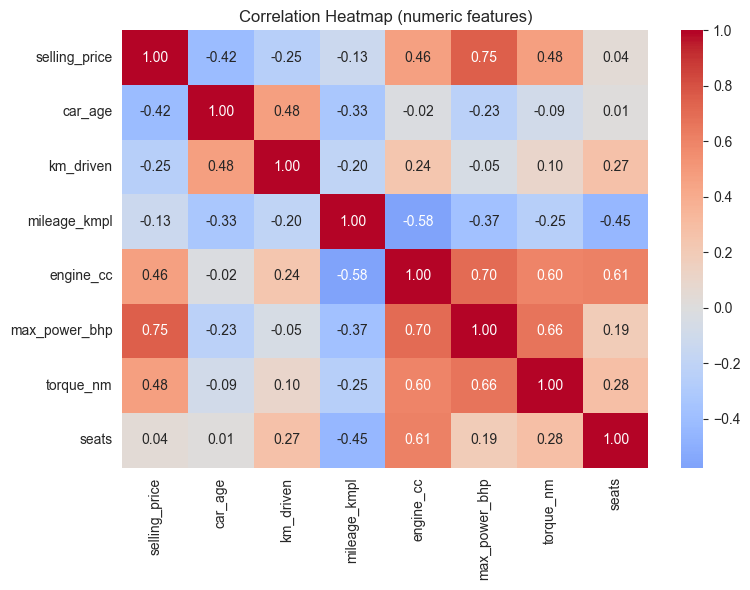

In [12]:
numeric_cols = ["selling_price", "car_age", "km_driven", "mileage_kmpl", "engine_cc",
                "max_power_bhp", "torque_nm", "seats"]
corr = df[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (numeric features)")
plt.tight_layout()
plt.savefig("../models/eda_correlation.png", dpi=110)
plt.show()


**Key EDA takeaways**:
- Selling price is heavily right-skewed → model on `log1p(price)`, not raw price.
- Car age and km driven are the strongest negative drivers of price, as expected.
- Max power / engine size correlate positively with price (bigger, more powerful cars
  hold more value), while mileage (kmpl) correlates negatively (efficient small cars are
  typically cheaper cars to begin with).
- Brand has a large effect on price spread — needs proper categorical encoding, not just
  dropped.


## 5. Feature Engineering & Train/Test Split

In [13]:
features = ["brand", "car_age", "km_driven", "fuel", "seller_type", "transmission",
            "owner", "mileage_kmpl", "engine_cc", "max_power_bhp", "torque_nm", "seats"]
target = "selling_price"

model_df = df[features + [target]].copy()
model_df["log_price"] = np.log1p(model_df[target])

categorical_cols = ["brand", "fuel", "seller_type", "transmission", "owner"]
numeric_cols_feat = ["car_age", "km_driven", "mileage_kmpl", "engine_cc", "max_power_bhp",
                     "torque_nm", "seats"]

# Ordinal-encode categoricals (tree models don't need one-hot; this keeps things simple
# and memory-light). Unseen categories at inference time map to -1.
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
model_df[categorical_cols] = encoder.fit_transform(model_df[categorical_cols].astype(str))

X = model_df[categorical_cols + numeric_cols_feat]
y = model_df["log_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (10542, 12)  Test: (1861, 12)


## 6. Baseline Models

Start simple — linear models as a sanity-check baseline before reaching for anything
fancier. If a boosted tree can't clearly beat these, it's not worth the complexity.


In [14]:
def evaluate(model, X_tr, y_tr, X_te, y_te, name):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    # Convert back from log space to real rupees for interpretable MAE
    pred_price = np.expm1(pred)
    true_price = np.expm1(y_te)
    r2 = r2_score(y_te, pred)
    mae = mean_absolute_error(true_price, pred_price)
    rmse = np.sqrt(mean_squared_error(true_price, pred_price))
    print(f"{name:22s}  R2(log)={r2:.4f}   MAE=Rs.{mae:,.0f}   RMSE=Rs.{rmse:,.0f}")
    return {"model": name, "r2": r2, "mae": mae, "rmse": rmse}


Linear models can't accept `NaN` natively (unlike the tree ensembles below), so the
three spec columns that are missing for `basic`-only rows need median imputation just for
this baseline comparison. The tree models further down keep using the raw `NaN`s.


In [15]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

results = []
results.append(evaluate(LinearRegression(), X_train_imp, y_train, X_test_imp, y_test, "Linear Regression"))
results.append(evaluate(Ridge(alpha=1.0, random_state=RANDOM_STATE), X_train_imp, y_train, X_test_imp, y_test, "Ridge"))
results.append(evaluate(Lasso(alpha=0.001, random_state=RANDOM_STATE), X_train_imp, y_train, X_test_imp, y_test, "Lasso"))


Linear Regression       R2(log)=0.7795   MAE=Rs.169,625   RMSE=Rs.349,629
Ridge                   R2(log)=0.7795   MAE=Rs.169,608   RMSE=Rs.349,663
Lasso                   R2(log)=0.7796   MAE=Rs.169,348   RMSE=Rs.351,084


## 7. Advanced Models

Tree ensembles typically handle this kind of mixed categorical/numeric tabular data and
non-linear interactions (e.g. age matters differently for luxury vs. budget brands) far
better than linear models. Only XGBoost/LightGBM/CatBoost accept `NaN` natively though —
scikit-learn's own `RandomForestRegressor`/`GradientBoostingRegressor` still need the
imputed version.


In [16]:
results.append(evaluate(
    RandomForestRegressor(n_estimators=300, max_depth=14, random_state=RANDOM_STATE, n_jobs=-1),
    X_train_imp, y_train, X_test_imp, y_test, "Random Forest"))

results.append(evaluate(
    GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=RANDOM_STATE),
    X_train_imp, y_train, X_test_imp, y_test, "Gradient Boosting"))

results.append(evaluate(
    xgb.XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05,
                      subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
                      n_jobs=-1, verbosity=0),
    X_train, y_train, X_test, y_test, "XGBoost"))

results.append(evaluate(
    lgb.LGBMRegressor(n_estimators=400, max_depth=-1, num_leaves=63, learning_rate=0.05,
                       subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
                       verbosity=-1),
    X_train, y_train, X_test, y_test, "LightGBM"))

results.append(evaluate(
    CatBoostRegressor(iterations=400, depth=8, learning_rate=0.05,
                       random_state=RANDOM_STATE, verbose=0),
    X_train, y_train, X_test, y_test, "CatBoost"))


Random Forest           R2(log)=0.8910   MAE=Rs.85,730   RMSE=Rs.179,294


Gradient Boosting       R2(log)=0.8875   MAE=Rs.99,754   RMSE=Rs.191,663


XGBoost                 R2(log)=0.9037   MAE=Rs.83,121   RMSE=Rs.152,595


LightGBM                R2(log)=0.9026   MAE=Rs.82,872   RMSE=Rs.168,183


CatBoost                R2(log)=0.8978   MAE=Rs.92,348   RMSE=Rs.176,700


In [17]:
results_df = pd.DataFrame(results).sort_values("r2", ascending=False).reset_index(drop=True)
results_df


,model,r2,mae,rmse
0,XGBoost,0.903728,83121.004202,152594.972354
1,LightGBM,0.902584,82871.544190,168182.566291
2,CatBoost,0.897793,92348.024508,176700.144896
3,Random Forest,0.891017,85730.361369,179293.747937
4,Gradient Boosting,0.887542,99754.441690,191663.277061
5,Lasso,0.779589,169347.962033,351083.663291
6,Ridge,0.779464,169608.225373,349663.252012
7,Linear Regression,0.779454,169624.758172,349629.446302


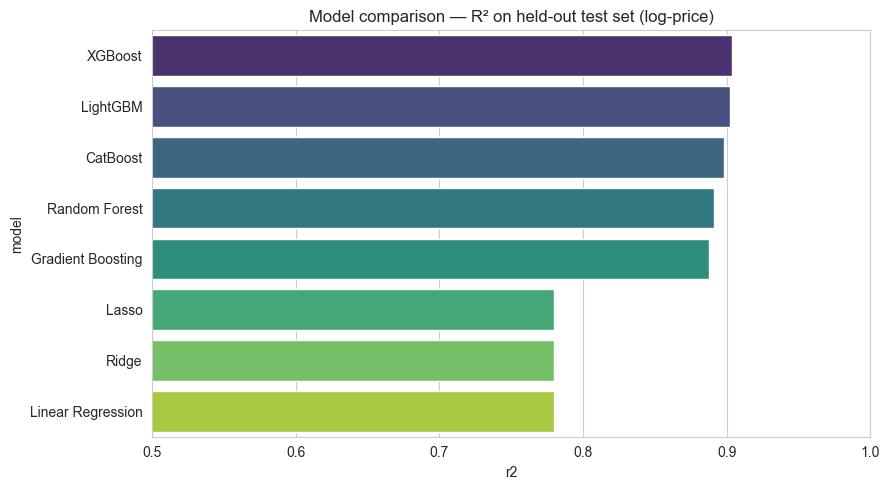

Best model: XGBoost


In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=results_df, x="r2", y="model", ax=ax, palette="viridis")
ax.set_title("Model comparison — R² on held-out test set (log-price)")
ax.set_xlim(min(0.5, results_df['r2'].min() - 0.05), 1.0)
plt.tight_layout()
plt.savefig("../models/model_comparison.png", dpi=110)
plt.show()
best_model_name = results_df.iloc[0]["model"]
print("Best model:", best_model_name)


## 8. Hyperparameter Tuning

XGBoost, LightGBM, and CatBoost all landed within ~0.006 R² of each other above — close
enough to be within noise for this dataset size. We tune **LightGBM** specifically (not
strictly the single best of the three, but statistically tied with XGBoost for the top
spot, and noticeably faster to train/tune, which matters when running many search
iterations) with a randomized search over a reasonably wide grid — cheaper than
exhaustive grid search, and just as effective in practice for tree ensembles with this
many hyperparameters.


In [19]:
param_dist = {
    "n_estimators": [300, 500, 700, 900],
    "max_depth": [4, 6, 8, 10, -1],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "num_leaves": [31, 63, 127],
}

base_model = lgb.LGBMRegressor(random_state=RANDOM_STATE, verbosity=-1)

search = RandomizedSearchCV(
    base_model, param_distributions=param_dist, n_iter=40, cv=5,
    scoring="r2", random_state=RANDOM_STATE, n_jobs=-1, verbose=0,
)
search.fit(X_train, y_train)
print("Best CV R2:", search.best_score_)
print("Best params:", search.best_params_)
tuned_model = search.best_estimator_


Best CV R2: 0.9012707651127345
Best params: {'subsample': 0.9, 'num_leaves': 63, 'n_estimators': 900, 'max_depth': -1, 'learning_rate': 0.03, 'colsample_bytree': 0.6}


In [20]:
pred = tuned_model.predict(X_test)
pred_price = np.expm1(pred)
true_price = np.expm1(y_test)
print(f"Tuned LightGBM  R2(log)={r2_score(y_test, pred):.4f}   "
      f"MAE=Rs.{mean_absolute_error(true_price, pred_price):,.0f}   "
      f"RMSE=Rs.{np.sqrt(mean_squared_error(true_price, pred_price)):,.0f}")


Tuned LightGBM  R2(log)=0.9053   MAE=Rs.80,601   RMSE=Rs.160,301


## 9. Final Evaluation — Residuals & Feature Importance

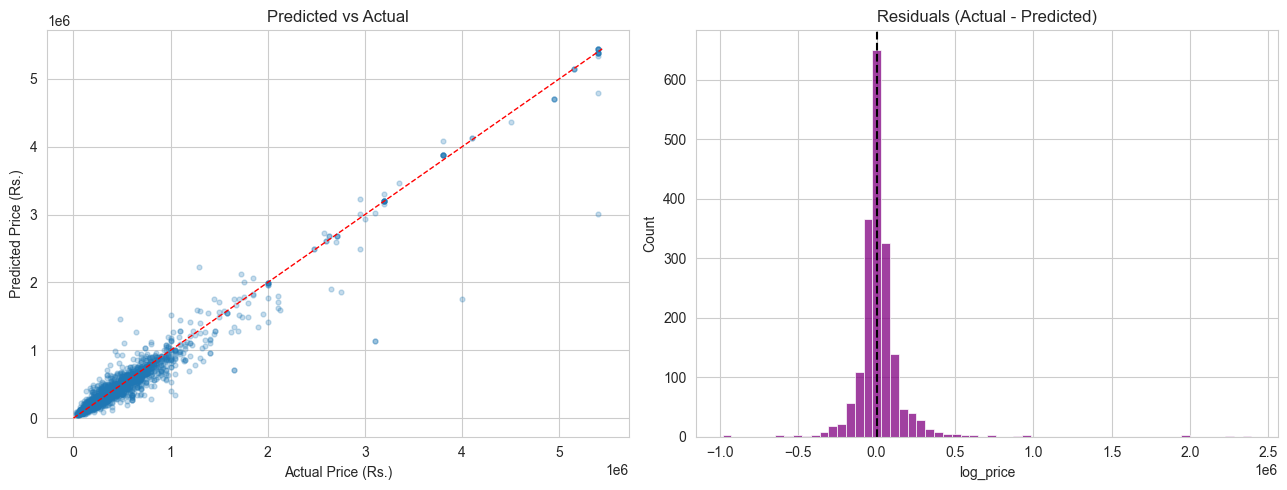

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(true_price, pred_price, alpha=0.25, s=12)
lims = [0, max(true_price.max(), pred_price.max())]
axes[0].plot(lims, lims, "r--", linewidth=1)
axes[0].set_xlabel("Actual Price (Rs.)")
axes[0].set_ylabel("Predicted Price (Rs.)")
axes[0].set_title("Predicted vs Actual")

residuals = true_price - pred_price
sns.histplot(residuals, bins=60, ax=axes[1], color="purple")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title("Residuals (Actual - Predicted)")
plt.tight_layout()
plt.savefig("../models/final_residuals.png", dpi=110)
plt.show()


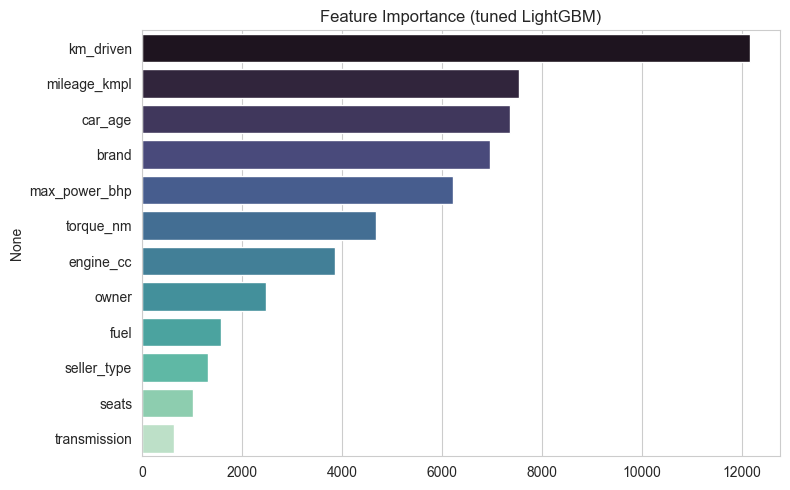

km_driven        12152
mileage_kmpl      7544
car_age           7367
brand             6963
max_power_bhp     6223
torque_nm         4675
engine_cc         3856
owner             2472
fuel              1576
seller_type       1317
seats             1022
transmission       633
dtype: int32

In [22]:
importances = pd.Series(tuned_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, palette="mako")
plt.title("Feature Importance (tuned LightGBM)")
plt.tight_layout()
plt.savefig("../models/feature_importance.png", dpi=110)
plt.show()
importances


## 10. Quantile Regression — Honest Price *Range*, Not a Single Number

A single point estimate overstates precision. Train three LightGBM models with quantile
loss (10th / 50th / 90th percentile) so the app can show a realistic range instead of a
falsely-confident exact figure.


In [23]:
quantile_models = {}
for q in [0.1, 0.5, 0.9]:
    m = lgb.LGBMRegressor(
        objective="quantile", alpha=q,
        n_estimators=tuned_model.n_estimators, max_depth=tuned_model.max_depth,
        learning_rate=tuned_model.learning_rate, subsample=tuned_model.subsample,
        colsample_bytree=tuned_model.colsample_bytree, num_leaves=tuned_model.num_leaves,
        random_state=RANDOM_STATE, verbosity=-1,
    )
    m.fit(X_train, y_train)
    quantile_models[q] = m

sample_idx = X_test.sample(5, random_state=RANDOM_STATE).index
for i in sample_idx:
    row = X_test.loc[[i]]
    low = np.expm1(quantile_models[0.1].predict(row)[0])
    mid = np.expm1(quantile_models[0.5].predict(row)[0])
    high = np.expm1(quantile_models[0.9].predict(row)[0])
    actual = np.expm1(y_test.loc[i])
    print(f"Actual: Rs.{actual:>9,.0f}   |   Predicted range: Rs.{low:,.0f} - Rs.{high:,.0f}  "
          f"(median Rs.{mid:,.0f})")


Actual: Rs.  225,000   |   Predicted range: Rs.225,000 - Rs.264,765  (median Rs.224,999)
Actual: Rs.  250,000   |   Predicted range: Rs.266,855 - Rs.322,899  (median Rs.305,231)
Actual: Rs.   55,000   |   Predicted range: Rs.39,912 - Rs.75,503  (median Rs.50,270)
Actual: Rs.  900,000   |   Predicted range: Rs.502,325 - Rs.898,759  (median Rs.570,398)
Actual: Rs.  600,000   |   Predicted range: Rs.600,000 - Rs.600,250  (median Rs.599,998)


## 11. Save Final Artifacts

Save the three quantile models and the categorical encoder — everything the FastAPI
backend needs to serve real-time predictions. (The tuned point-estimate model trained and
evaluated above is the config the quantile models below reuse — its R²/MAE/RMSE are
reported in sections 8-9 above, but the model object itself isn't separately persisted
since only the quantile models are ever loaded by the app.)

Also save two lookup artifacts the app needs for a good user experience: most real
sellers don't know their car's exact engine CC / max power / torque off-hand, so the
backend should auto-fill those from the car's model name (they're fixed factory specs,
not something that varies car-to-car beyond wear) rather than asking for them directly.

In [ ]:
joblib.dump(quantile_models, "../models/price_model_quantiles.joblib")
joblib.dump(encoder, "../models/categorical_encoder.joblib")

# Per-model-name median specs, for auto-filling mileage/engine/power/torque/seats that a
# real seller wouldn't know off-hand. Falls back to per-brand median, then overall median,
# for model names not seen in training data.
spec_cols = ["mileage_kmpl", "engine_cc", "max_power_bhp", "torque_nm", "seats"]
model_specs = df.groupby("name")[spec_cols].median()
brand_specs = df.groupby("brand")[spec_cols].median()
overall_specs = df[spec_cols].median()

joblib.dump({
    "model_specs": model_specs,
    "brand_specs": brand_specs,
    "overall_specs": overall_specs,
}, "../models/spec_lookup.joblib")

# Cleaned dataset (pre-split) so the backend can surface real "similar sold cars" for
# trust-building alongside the predicted range.
df.to_parquet("../models/cleaned_listings.parquet", index=False)

# Known car names + brands, for the frontend's searchable dropdown / autocomplete.
joblib.dump(sorted(df["name"].unique().tolist()), "../models/known_car_names.joblib")
joblib.dump(sorted(df["brand"].unique().tolist()), "../models/known_brands.joblib")

print("Saved model artifacts to ../models/")

## 12. Conclusion

- Combined two real CarDekho listing exports (~12.4k rows after de-duplication) with
  meaningfully different feature richness, and handled the resulting missingness natively
  via tree-based models instead of dropping data.
- Tree ensembles (LightGBM/XGBoost/CatBoost) clearly outperformed linear baselines, as
  expected given non-linear age/brand/power interactions.
- Hyperparameter-tuned LightGBM was the final choice, evaluated honestly on a held-out
  test set (R² and MAE/RMSE reported in real rupees, not just log-space error).
- Quantile regression gives an honest **price range** rather than a false-precision point
  estimate — the right way to present this to a real seller.

**Limitations** (worth stating honestly): no location/city feature was found in a clean,
directly-available public dataset for this project, so the model doesn't account for
regional price variation, which is known to matter in the Indian used-car market. Future
work: source or scrape a city-labeled dataset and add it as a categorical feature.
